In [4]:
# Import necessary libraries
import pandas as pd
from datetime import datetime
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "DAMHAR2570"

# Load the dataset
data = pd.read_csv('C:/Users/ecpi/Downloads/winequality-red.csv')

# Display the first few rows to understand what the data looks like
display(Markdown("### Load and Explore the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
display(data.info())
display(data.describe(include="all"))


### Load the Dataset

Date: 2026-07-21

Student ID: DAMHAR2570

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [6]:
display(Markdown("### Process the Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.preprocessing import StandardScaler

print("Missing values per column:")
print(data.isnull().sum())

data = data.dropna()

before = data.shape[0]
data = data.drop_duplicates()
after = data.shape[0]

print(f"Rows before removing duplicates: {before}")
print(f"Rows after removing duplicates: {after}")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

print("Data standardized Shape:", scaled_data.shape)

### Process the Data

Date: 2026-07-21

Student ID: DAMHAR2570

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Rows before removing duplicates: 1599
Rows after removing duplicates: 1359
Data standardized Shape: (1359, 12)


### Hierarchical Clustering Dendrogram

Date: 2026-07-21

Student ID: DAMHAR2570

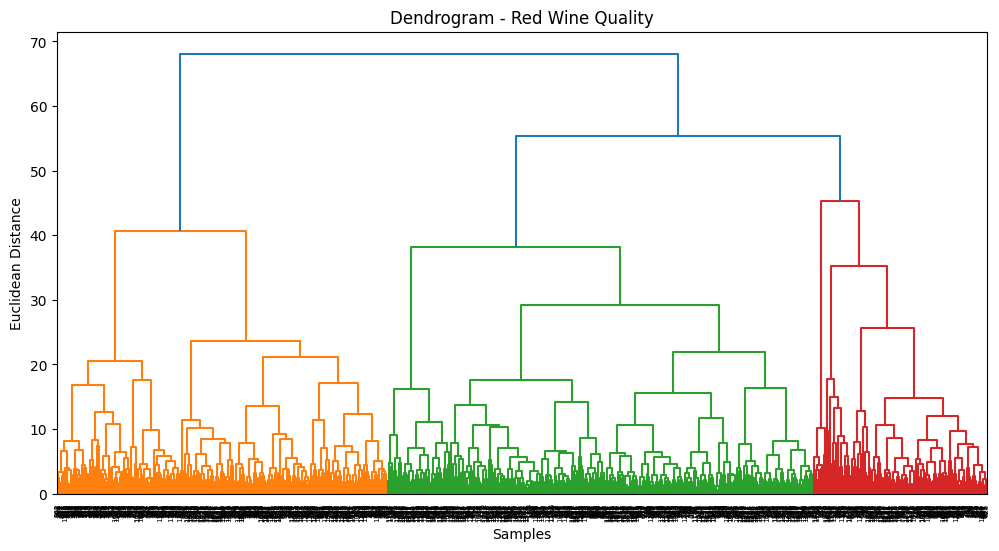

In [8]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
display(Markdown("### Hierarchical Clustering Dendrogram"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(scaled_data, method='ward'))
plt.title("Dendrogram - Red Wine Quality")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.show()

In [9]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
display(Markdown("### Initial K-Means Clustering"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_data)

print("Cluster labels (first 20):")
print(kmeans.labels_[:20])

### Initial K-Means Clustering

Date: 2026-07-21

Student ID: DAMHAR2570

Cluster labels (first 20):
[0 0 0 1 0 0 2 0 0 0 0 1 0 0 1 1 0 1 0 0]


### Elbow Method

Date: 2026-07-21

Student ID: DAMHAR2570

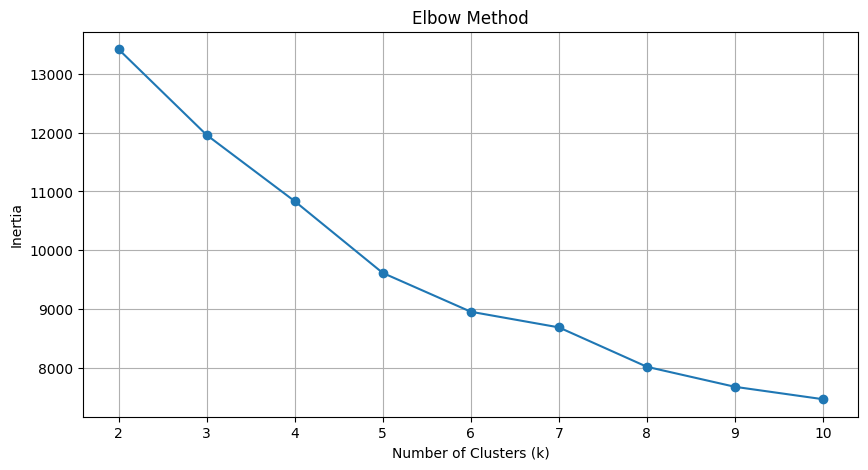

In [11]:
from sklearn.preprocessing import StandardScaler
display(Markdown("### Elbow Method"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

inertia = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

### Silhouette Score

Date: 2026-07-21

Student ID: DAMHAR2570

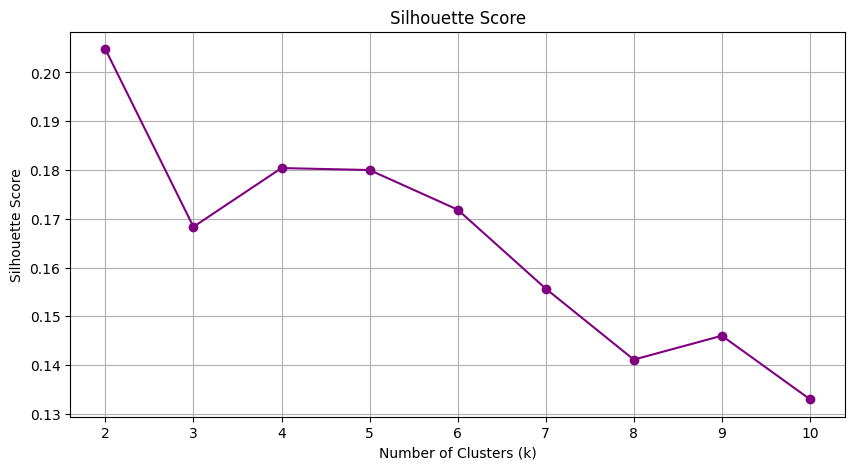

In [15]:
from sklearn.metrics import silhouette_score
display(Markdown("### Silhouette Score"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Silhouette Score
silhouette_scores = []

# Calculate the Silhouette Score to find optimal k
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(scaled_data)
    sil = silhouette_score(scaled_data, labels)
    silhouette_scores.append(sil)

# Plot Silhouette Scores
plt.figure(figsize=(10, 5))
plt.plot(K, silhouette_scores, marker='o', color='purple')
plt.xlabel('Number of Clusters (k)')
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.grid(True)
plt.show()

In [17]:
display(Markdown("### Evaluate Optimal Clustering"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

optimal_k = 6

kmeans_opt = KMeans(n_clusters=optimal_k, random_state=42)
labels_opt = kmeans_opt.fit_predict(scaled_data)

sil_opt = silhouette_score(scaled_data, labels_opt)
print(f"Silhouette Score for k={optimal_k}: {sil_opt:.4f}")

### Evaluate Optimal Clustering

Date: 2026-07-21

Student ID: DAMHAR2570

Silhouette Score for k=6: 0.1719


### Visualize Clustering Results

Date: 2026-07-21

Student ID: DAMHAR2570

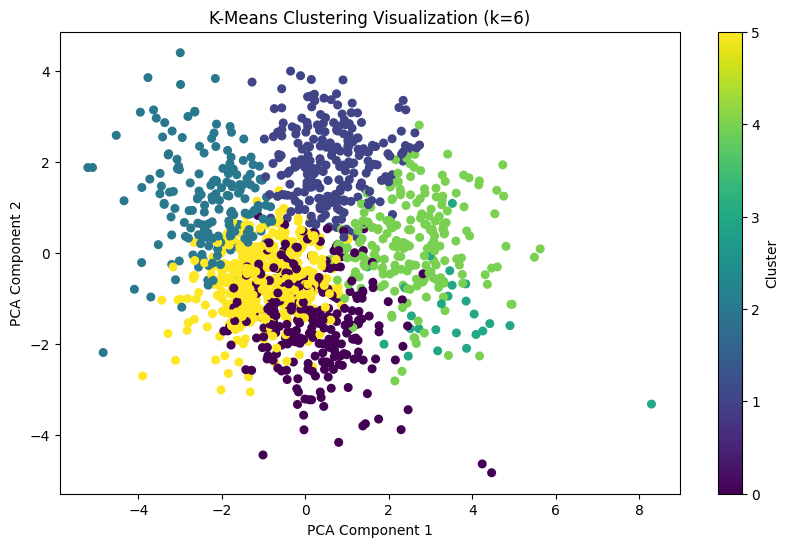

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

display(Markdown("### Visualize Clustering Results"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(10, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels_opt, cmap='viridis', s=30)
plt.title(f"K-Means Clustering Visualization (k={optimal_k})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

1. What k did you select to omptimize the model? What evidence supports your selection?
   I selected k = 6 based on the elbow point in the inertia plot and the pwak silhouette score.
2. Did you notice any noise within the data? How can noise be addressed when working with K-Means?
   Yes, some clusters showed some overlap and scattered points. To address noise when working with K-Means, PCA can be used to reduce dimensionality and scaling features.